In [93]:
import rasterio as rio 
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show
from skimage import exposure

In [ ]:

def image_prepro(img, dtype=np.float32):
    p2, p98 = np.percentile(img, (2, 98))
    image = exposure.rescale_intensity(img, in_range=(p2, p98), out_range=dtype)#/ 100_000

    return image
    # Plot the RGB image
    #show(image.transpose(2, 0, 1), transform=img.transform)

def norm(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

def write_png(rgb, fp:str = '../data/img/rgb.png'):
    from rasterio.plot import reshape_as_raster
    with rio.open(fp, 'w',
            driver='PNG',
            height=rgb.shape[0],
            width=rgb.shape[1],
            count=3,
            dtype='uint8',
            nodata=0,) as dst:
            dst.write(reshape_as_raster(rgb))

In [ ]:
with rio.open("../data/s2/Sentinel2_2026-06-23.tif") as src:
    r= norm(src.read(1))
    g = norm(src.read(2))
    b = norm(src.read(3))

    img = np.stack([r,g,b])#.transpose((2,1,0))
    img = image_prepro(img)

show(img)

<positron-console-cell-97>:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
<positron-console-cell-97>:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
<positron-console-cell-97>:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).


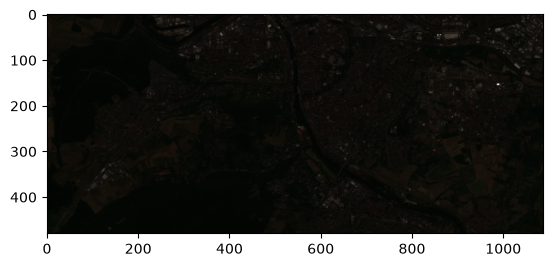

In [103]:
plt.imshow(np.dstack([r,g,b]))

In [101]:
print(img.min(), img.max())

0.0 1.0


In [102]:
write_png((img * 255).astype(np.uint8).transpose(1,2,0), fp="../data/img/rbg_june.png")

/home/feds/projects/fieldmeasurements/.venv/lib/python3.13/site-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
